In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.signal import wiener, butter, freqs, convolve, freqz
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
import cv2
from scipy.signal import convolve2d as conv2
from skimage import color, data, restoration
from smooth_POD_ROM.reduced_order_model import pulse, delta_n_width, train_ROM, L2_error, zielfunktion
from smooth_POD_ROM.pre_processing import convolve_f, gaussian_f, gaussian, smoothen
from smooth_POD_ROM.post_processing import richardson_lucy, post_process
from scipy.optimize import minimize

In [3]:
# import numpy as np
# from scipy.ndimage import gaussian_filter
# from datetime import datetime
# im_deconv = np.load("C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/wtf1.npy")
# relative_blur = np.load("C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/wtf2.npy")


# sgm = 2200/1000
# dx = 1/100
# truncate = 8
# mode = "wrap"
# t0 = datetime.now()
# blurred = gaussian_filter(
#     im_deconv, sigma=sgm/dx, truncate=truncate, mode=mode)  # + eps
# t1 = datetime.now()
# error_estimate = gaussian_filter(
#     relative_blur, sigma=sgm/dx, truncate=truncate, mode=mode)
# t2 = datetime.now()
# print((t1-t0).total_seconds())
# print((t2-t1).total_seconds())
# # ads
# # for sgm in [10, 50, 100, 500, 1000, 2000]:
# #     if sgm > 1000:
# #         truncate = 2
# #     if sgm > 100:
# #         truncate = 4
# #     dx = 1
# #     mode="wrap"
# #     t2 = datetime.now()
# #     error_estimate = gaussian_filter(
# #         relative_blur, sigma=sgm, truncate=8, mode=mode)
# #     t3 = datetime.now()
# #     print(_, np.min(relative_blur), np.max(
# #         relative_blur), (t3-t2).total_seconds())

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

8.030570172000001


In [5]:
m, n = 1000, 10
n_test = 11
x = np.linspace(0, 1, m, endpoint=False)
mu_train = np.linspace(0.0, 1, n, endpoint=False)[:, None]  # +1/(2*n)
#mu_test = np.array([0.2, 0.22, 0.225, 0.23,  0.24, 0.25])[:, None]
mu_test = np.linspace(0.15, 0.2, n_test, endpoint=True)[:, None]
mu_val = x.copy()

interpolatable = (mu_train[0]<mu_val) & (mu_val<mu_train[-1])
mu_val = mu_val[interpolatable][:, None]

sigma = 0.05
num_iter1 = 10
num_iter2 = 100
mode = "constant"
rank = n
dx = 1/m
c = 2
shape = (m,)
clip = True

In [6]:
def plot_paramspace(X, ax=None):
    if not ax:
        print("new ax")
        fig, ax = plt.subplots(figsize=(4.59/2.54, 4.59/2.54))
    ax.imshow(X, interpolation="none", extent=(0, 1, 0, 1), aspect="auto")
    ax.set_xlabel("$\mu$")
    ax.set_ylabel("$x$")
    return ax

In [7]:
X_train = np.empty((m, len(mu_train)))
X_test = np.zeros((m, len(mu_test)))
X_val = np.zeros((m, len(mu_val)))

for _mu, _X in zip([mu_train, mu_test, mu_val], [X_train, X_test, X_val]):
    for j, mu_j in enumerate(_mu):
        y = pulse(x, mu_j)
        _X[:, j] = y
X_train_s = smoothen(X_train, sigma/dx, x.shape, truncate=12)
X_test_s = smoothen(X_test, sigma/dx, x.shape, truncate=12)
X_val_s = smoothen(X_val, sigma/dx, x.shape, truncate=12)

# Fig. 1

C:\Users\florianma\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


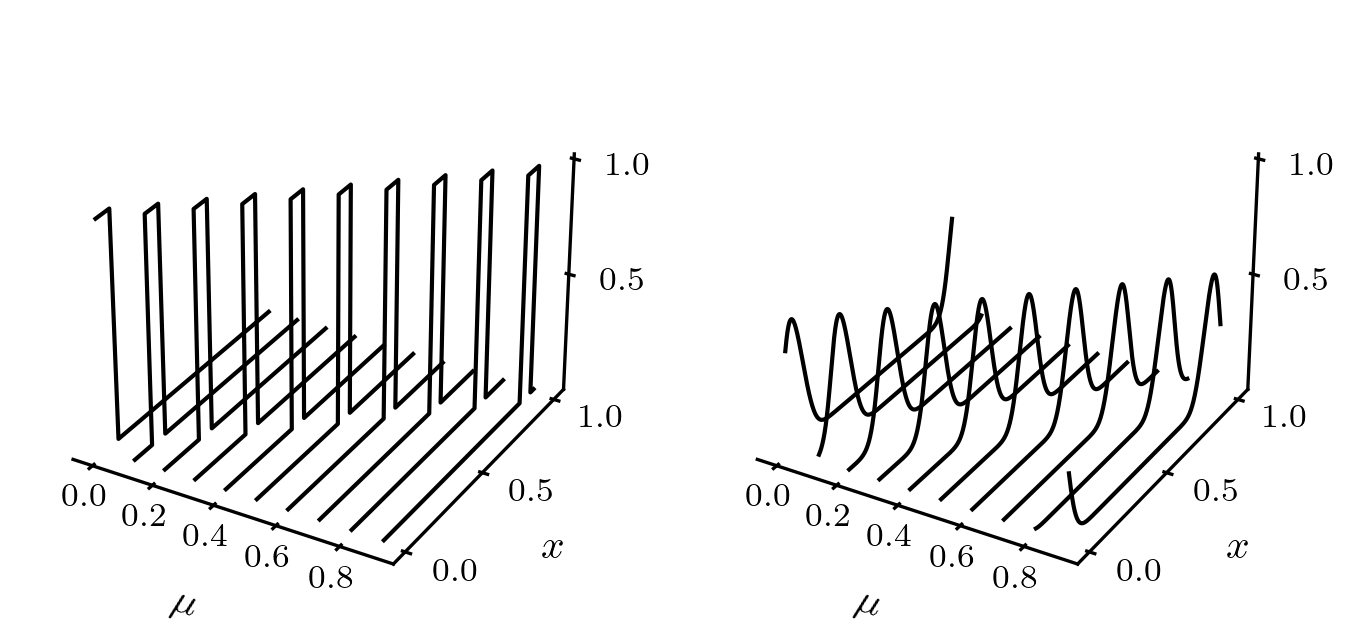

In [8]:
fig = plt.figure(figsize=(page_width_in, page_width_in/2), facecolor='white')
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

for i in range(len(mu_train)):
    ax1.plot(np.ones_like(x)*mu_train[i], x, X_train[:, i], "k-", lw=1)
    ax2.plot(np.ones_like(x)*mu_train[i], x, X_train_s[:, i], "k-", lw=1)
for ax in (ax1, ax2):
    ax.xaxis.labelpad = -5
    ax.yaxis.labelpad = -5
    xticks = [0.0, 0.2, 0.4, 0.6, 0.8]
    yticks = [0.0, 0.5, 1.0]
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_zticks([0.5, 1.0])
    ax.tick_params(axis='x', which='major', pad=-5)
    ax.tick_params(axis='y', which='major', pad=-2)
    ax.tick_params(axis='z', which='major', pad=0)
    ax.set_yticklabels(yticks, va='baseline', ha='left')
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        for tick in axis.get_major_ticks():
            tick.label1.set_fontsize(8)  # for some reasons it does not match
        axis.pane.set_edgecolor('white')

    ax.grid(False)
    ax.set_facecolor('white')
    ax.xaxis.pane.fill = False  # Remove the background pane
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.set_xlabel("$\mu$")
    ax.set_ylabel("$x$")
plt.show()


In [9]:
standard_rom = train_ROM(mu_train, X_train, rank=rank)
X_test_ROM = standard_rom.predict(mu_test).T
X_val_ROM = standard_rom.predict(mu_val).T

X_train_s = smoothen(X_train, sigma/dx, shape)
smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
X_test_sROM = smooth_rom.predict(mu_test).T
X_val_sROM = smooth_rom.predict(mu_val).T

X_test_sROMs = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter1,
                            shape, clip=clip, progress=False)
X_test_sROMs2 = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter2,
                            shape, clip=clip, progress=False)

pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/Pulse/"
np.save(pth+"X_test.npy", X_test)
np.save(pth+"X_test_s.npy", X_test_s)
np.save(pth+"X_test_ROM.npy", X_test_ROM)
np.save(pth+"X_test_sROM.npy", X_test_sROM)

\\files.ad.ife.no\MatPro_files\Florian\Repositoties\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:24: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


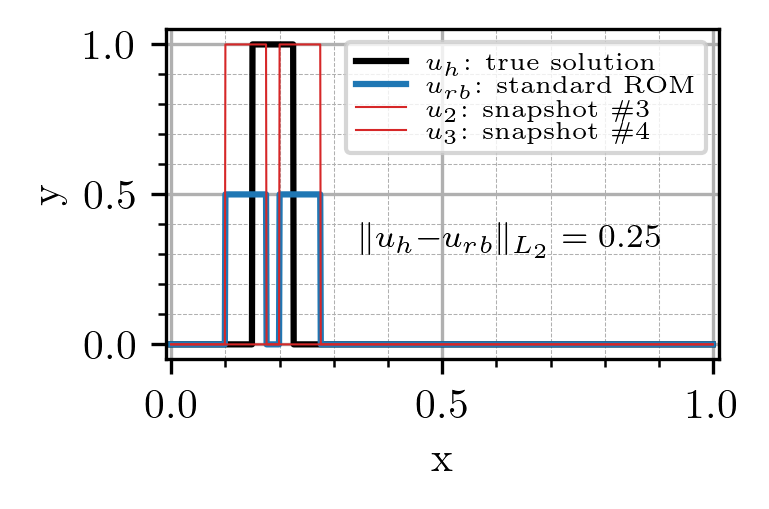

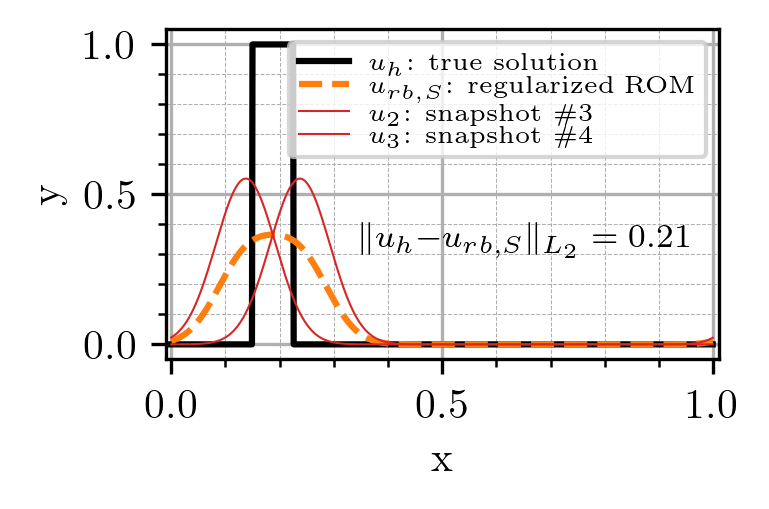

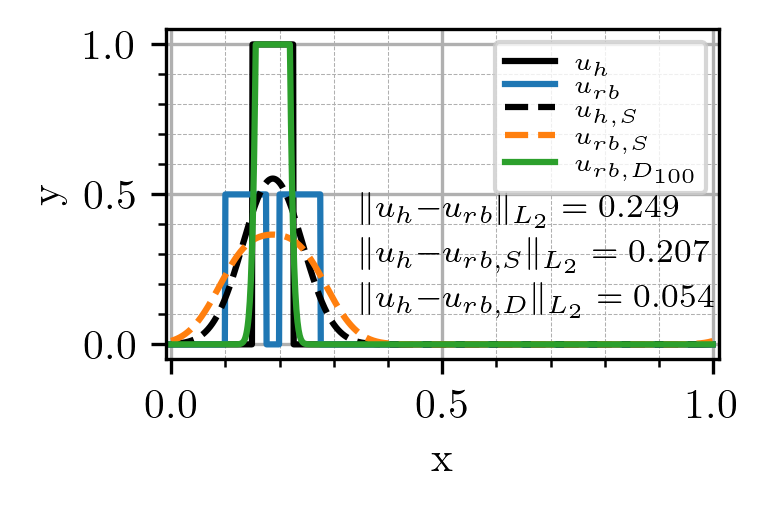

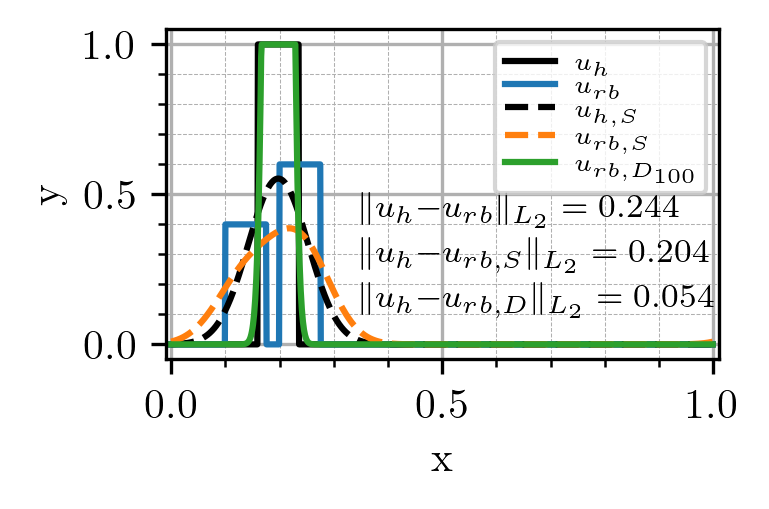

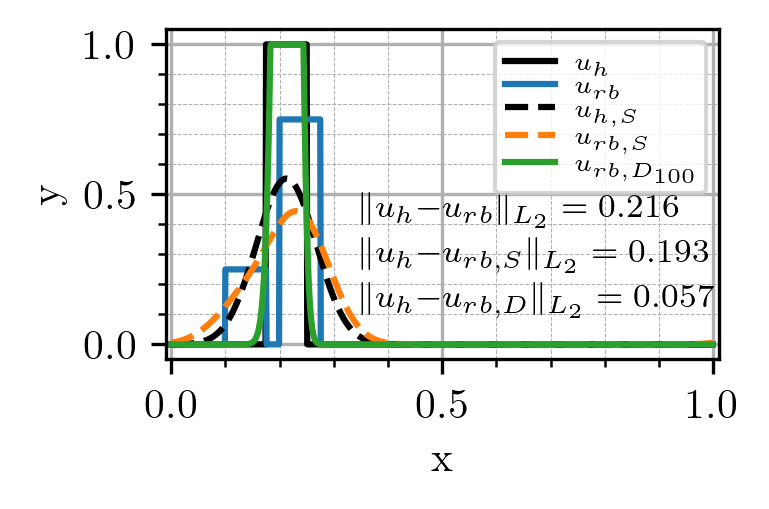

In [10]:
mu_plot = 0.2

i_c = 0  # snapshots centered between 2 training points
for _X, _X_R, lbl, col in zip([X_train, X_train_s], [X_test_ROM, X_test_sROM],
                              ["$u_{rb}$: standard ROM", "$u_{rb, S}$: regularized ROM"], ["C0-", "C1--"]):
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    #plt.plot(x, pulse(x, mu_plot), "kx-", ms=4, markevery=markevery, label="$u_h$: true solution")
    plt.plot(x, X_test[:, i_c], "k-", ms=4, markevery=markevery, label="$u_h$: true solution")
    #plt.plot(x, X_test_ROM[:, 0], "b.-", label="ROM")
    plt.plot(x, _X_R[:, i_c], col, ms=4, markevery=markevery, label=lbl)
    #plt.plot(x, X[:, 3], "r--", lw=1, label="closest snapshot (left)")
    #plt.plot(x, X[:, 4], "r--", lw=1, label="closest snapshot (right)")
    plt.plot(x, _X[:, 1], "C3-", lw=.5, ms=4, markevery=(30, markevery), label="$u_{2}$: snapshot \#3")
    plt.plot(x, _X[:, 2], "C3-", lw=.5, ms=4, markevery=(30, markevery), label="$u_{3}$: snapshot \#4")
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    plt.legend()
    e = np.mean((X_test[:, 0]-_X_R[:, 0])**2)**.5
    ax.text(0.35, 0.35, "$\|u_h-$"+lbl.split(":")[0]+"$\|_{L_2}"+"={:.2f}$".format(e), fontsize=8, va="center")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.05, 1.05)
    plt.show()

if m == 1001:
    a_list = [0, 5, 10]
else:
    a_list = [0, 2, 5]

for j in a_list:
    markevery = 45
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    plt.plot(x, X_test[:, j], "k-", ms=4, markevery=(0, markevery), label="$u_h$") # : true solution
    plt.plot(x, X_test_ROM[:, j], "C0-", ms=4, markevery=(10, markevery), label="$u_{rb}$") # : standard ROM
    plt.plot(x, X_test_s[:, j], "k--", ms=4, markevery=(20, markevery), label="$u_{h, S}$") # : regularized true solution
    plt.plot(x, X_test_sROM[:, j], "C1--", ms=4, markevery=markevery, label="$u_{rb, S}$") # : regularized ROM
    plt.plot(x, X_test_sROMs2[:, j], "C2-", ms=4, markevery=(30, markevery), label="$u_{rb, D_{100}}$") # : deconvolved reg. ROM
#     plt.plot(x, X_test_sROMs2[:, j], "C3|-", ms=4, markevery=markevery, label="$u_{rb, D_{100}}$") # : deconvolved reg. ROM
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 2, 21, endpoint=True), minor=True)
    
    e = np.mean((X_test[:, j]-X_test_ROM[:, j])**2)**.5
    ax.text(0.35, 0.45, "$\|u_h{-u_{rb}}\|_{L_2}"+"={:.3f}$".format(e), fontsize=8, va="center")
    
    e = np.mean((X_test[:, j]-X_test_sROM[:, j])**2)**.5
    ax.text(0.35, 0.3, "$\|u_h{-u_{rb,S}}\|_{L_2}"+"={:.3f}$".format(e), fontsize=8, va="center")
    
    e = np.mean((X_test[:, j]-X_test_sROMs2[:, j])**2)**.5
    ax.text(0.35, 0.15, "$\|u_h{-u_{rb,D}}\|_{L_2}"+"={:.3f}$".format(e), fontsize=8, va="center")
    
#     e = np.mean((X_test[:, j]-X_test_sROMs2[:, j])**2)**.5
#     ax.text(0.35, 0.0, "$\|u_h{-u_{rb,D_{1000}}}\|_{L_2}"+"={:.3f}$".format(e), fontsize=8, va="center")
    
    plt.grid(True, which='minor', linestyle='--', lw=0.25)
    plt.grid(True, which='major', linestyle='-')
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.05, 1.05)
    plt.show()

In [11]:
# TODO: brute force sigma and c

# brute force search for sigma_s (per snapshot!)

In [ ]:
# for snapshots in mu_test
# for sigma_s in [0.0, ..., 0.2]
# sigma_d = 2*sigma_s
# smooth rom
c = 2
sgms = np.linspace(0, 0.1, 21)
eROM = L2_error(X_test_ROM, X_test)
esROM = np.zeros((n_test, 21))
esROMs = np.zeros((n_test, 21))
esROMs2 = np.zeros((n_test, 21))
for i, sigma_s in enumerate(sgms):
    print(sigma_s)
    X_train_s = smoothen(X_train, sigma_s/dx, shape)
    smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
    X_test_sROM = smooth_rom.predict(mu_test).T
    esROM[:, i] = L2_error(X_test_sROM, X_test)
    # de smoothing
    X_test_sROMs = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
                                num_iter1, shape=shape, clip=clip)
    esROMs[:, i] = L2_error(X_test_sROMs, X_test)
    # de smoothing with a higher number of iterations
    X_test_sROMs2 = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
                                num_iter2, shape=shape, clip=clip)
    esROMs2[:, i] = L2_error(X_test_sROMs2, X_test)


me = 5
for p in range(n_test):
    print(mu_test[p])
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    plt.plot(sgms, np.full(sgms.shape, eROM[p]), "C0o-", ms=4, markevery=(1, me), label="$u_{rb}$")
    plt.plot(sgms, esROM[p, :], "C1--", ms=4, markevery=me, label="$u_{rb,S}$")
    plt.plot(sgms, esROMs[p, :], "C2x-", ms=4, markevery=(2, me), label="$u_{rb,D_{10}}$")
    plt.plot(sgms, esROMs2[p, :], "C3<-", ms=4, markevery=(3, me), label="$u_{rb,D_{100}}$")
    plt.legend()
    plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
    plt.xlabel("$\sigma_S$")
    plt.xlim(0, .1)
    plt.ylim(0, 0.4)
    ax.set_xticks(np.linspace(0, .1, 21, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, .4, 21, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    plt.show()

0.0
0.005
0.01
0.015
0.02
0.025


# brute force search for c (per snapshot!)

In [ ]:
# for snapshots in mu_test
# for sigma_s in [0.0, ..., 0.2]
# sigma_d = 2*sigma_s
# smooth rom
sigma_s = 0.05
cs = np.linspace(0, 10, 21)
eROM = L2_error(X_test_ROM, X_test)
esROMs = np.zeros((n_test, 21))
esROMs2 = np.zeros((n_test, 21))

X_train_s = smoothen(X_train, sigma_s/dx, shape)
smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
X_test_sROM = smooth_rom.predict(mu_test).T
esROM = L2_error(X_test_sROM, X_test)
for i, c in enumerate(cs):
    print(c)
    # de smoothing
    X_test_sROMs = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
                                num_iter1, shape=shape, clip=clip)
    esROMs[:, i] = L2_error(X_test_sROMs, X_test)
    # de smoothing with a higher number of iterations
    X_test_sROMs2 = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
                                num_iter2, shape=shape, clip=clip)
    esROMs2[:, i] = L2_error(X_test_sROMs2, X_test)

    
me = 5
for p in range(n_test):
    print(mu_test[p])
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    plt.plot(cs, np.full(cs.shape, eROM[p]), "C0o-", ms=4, markevery=(1, me), label="$u_{rb}$")
    plt.plot(cs, np.full(cs.shape, esROM[p]), "C1--", ms=4, markevery=me, label="$u_{rb,S}$")
    plt.plot(cs, esROMs[p, :], "C2x-", ms=4, markevery=(2, me), label="$u_{rb,D_{10}}$")
    plt.plot(cs, esROMs2[p, :], "C3<-", ms=4, markevery=(3, me), label="$u_{rb,D_{100}}$")
    plt.legend()
    plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
    plt.xlabel("$c$")
    plt.xlim(0, .1)
    plt.ylim(0, 0.4)
    ax.set_xticks(np.linspace(0, 10, 21, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, .4, 21, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    plt.show()

In [ ]:
bf = False
if bf:
    n_s = 41
    sgms = np.linspace(0.0, 0.2, n_s)
    e1 = np.zeros((len(mu_val), n_s),)-1
    e2 = np.zeros((len(mu_val), n_s),)-1

    esROM = np.empty(len(mu_val), )
    eROM = np.empty(len(mu_val), )
    esROMs = np.empty(len(mu_val), )
    sgm_opt = np.empty(len(mu_val), )

    for p in range(len(mu_val)):
#         if np.round(mu_val[p], decimals=3) not in mu_test:
#             continue
        exact = X_val[:, p]
        standard_ROM = X_val_ROM[:, p]
        blurred = np.copy(X_val_sROM[:, p])
        esROM[p] = np.mean((blurred-X_val[:, p])**2)**.5
        eROM[p] = np.mean((standard_ROM-X_val[:, p])**2)**.5


        for i, sgm in enumerate(sgms):
            deconvolved_RL = richardson_lucy(x, blurred, sgm, num_iter=num_iter1, damping=2, clip=clip)
            e1[p, i] = np.mean((deconvolved_RL-X_val[:, p])**2)**.5

        ind = np.argmin(e1[p])
        sgm_opt[p] = sgms[ind]
        esROMs[p] = e1[p, ind]

        print(p, mu_val[p], ind, sgm_opt[p], e1[p, ind])

        if np.round(mu_val[p], decimals=3) in [0.15, 0.175, 0.2]:
            for i, sgm in enumerate(sgms):
                deconvolved_RL = richardson_lucy(x, blurred, sgm, num_iter=num_iter2, damping=2, clip=clip)
                e2[p, i] = np.mean((deconvolved_RL-X_val[:, p])**2)**.5
            
            me = 10
            fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
            plt.plot(sgms, np.full(sgms.shape, eROM[p]), "C0o-", ms=4, markevery=(5, me), label="$u_{rb}$")
            plt.plot(sgms, np.full(sgms.shape, esROM[p]), "C1--", ms=4, markevery=me, label="$u_{rb,S}$")
            plt.plot(sgms, e1[p], "C2x-", ms=4, markevery=(5, me), label="$u_{rb,D_{10}}$")
            plt.plot(sgms, e2[p], "C3<-", ms=4, markevery=(20, me), label="$u_{rb,D_{100}}$")
            plt.legend()
            plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
            plt.xlabel("$\sigma_D$")
            plt.xlim(0, .2)
            plt.ylim(0, 0.4)
            plt.legend()
            ax.set_xticks(np.linspace(0, .2, 11, endpoint=True), minor=True)
            ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
            plt.grid(True, which='minor', linestyle='--', lw=.25)
            plt.grid(True, which='major', linestyle='-')
            plt.show()

            deconvolved_RL = richardson_lucy(x, blurred, sgm_opt[p], num_iter=num_iter1, damping=2, clip=clip)

            plt.plot(x, standard_ROM, "C0.", label="standard ROM")
            plt.plot(x, blurred, "C1.", label="smooth ROM")
            plt.plot(x, X_val[:, p], "C2.", label="exact solution")
            plt.plot(x, X_val_s[:, p], "C3.", label="exact solution (smooth)")
            plt.plot(x, deconvolved_RL, "C4.", label="richarson Lucy deconvolution")
            plt.legend()
            plt.xlabel("$x$")
            plt.ylabel("$y$")
            plt.show()


    plt.plot(mu_val, eROM, "C0.", label="standard ROM")
    plt.plot(mu_val, esROM, "C1.", label="smooth ROM")
    plt.plot(mu_val, esROMs, "C2.", label="RL")
    plt.xlabel("error")
    plt.xlabel("$\mu$")
    plt.legend()
    plt.show()

    print(np.mean(esROM/eROM))
    plt.plot(mu_val, sgm_opt, "C0.")
    plt.xlabel("$\mu$")
    plt.ylabel("$\sigma$")
    plt.show()

In [ ]:
if bf:
    plt.plot(mu_val, sgm_opt, "C0.")
    plt.ylim(0.05, 0.2)
    plt.show()

    ind = np.argmin(np.abs(sgms-sigma))
    plt.plot(mu_val, e1[:, ind], "C0.")

    ind = np.argmin(np.abs(sgms-2*sigma))
    fig, ax = plt.subplots()
    plt.plot(mu_val, e1[:, ind], "C1.")
    plt.plot(mu_val, np.min(e1, axis=1), "C2.")
    #plt.xlim(0.2, 0.5)
    #plt.ylim(1.8, 2.0)
    plt.xlabel("$\mu$")
    plt.ylabel("$e$")
    left, right, bottom, top = sgms[0], sgms[-1], mu_val[0, 0], mu_val[-1, 0]

    fig, ax2 = plt.subplots()
    plt.imshow(e1, vmin=0.0, vmax=0.15, extent=(left, right, bottom, top), origin="lower", interpolation="nearest")  # 
    plt.gca().set_aspect("auto")
    for p, _mu in enumerate(mu_val):
        d = np.min(np.abs(_mu-mu_train))
        ind2 = np.argmin(np.abs(sgms - (sigma+1*d)))

        ax.plot(_mu, e1[p, ind2], "r.")
        plt.plot(sigma+1*d, _mu, "b.", ms=1)

        ind = np.argmin(e1[p, :])
        plt.plot(sgms[ind], _mu, "r.", ms=1)
    plt.show()

# truncation leads to bad results

In [ ]:
n = 21
rank = 21
shape = (m,)

_X_train = np.empty((m, n))
_mu_train = np.linspace(0, 1, n, endpoint=True)[:, None]
for j, mu_j in enumerate(_mu_train):
    _X_train[:, j] = pulse(x, mu_j)

improvement, X_test_ROM, X_test_sROM, X_test_sROMs = zielfunktion([0.05, 2.0], x, _mu_train, _X_train, mu_test,
                                                                  X_test, rank, shape, num_iter2)

_X_train_s = smoothen(_X_train, sigma/dx, shape)

for j, mu_j in enumerate(mu_test):
    eR = np.mean((X_test_ROM[:, j]-X_test[:, j])**2)**.5
    esR = np.mean((X_test_sROM[:, j]-X_test[:, j])**2)**.5
    esRs = np.mean((X_test_sROMs[:, j]-X_test[:, j])**2)**.5
    print(eR, esR, esRs)
    plt.plot(X_test[:, j])
    plt.plot(X_test_ROM[:, j])
    plt.plot(X_test_sROM[:, j])
    plt.plot(X_test_sROMs[:, j])
    plt.title("{:.4f}, {:.4f}, {:.4f}".format(eR, esR, esRs))
    plt.show()

In [ ]:
# increase n, error? improvement?
sigma_opt, c_opt = 0.05, 4
NN = np.arange(3, 100, 1)
sigma_opt = 0.9117*NN**(-1.305)
c_opt = 37.039*NN**(-0.93)
eROM = np.zeros_like(NN)
n_iter = 100
for i, n in enumerate(NN):
    rank = n

    # generate training data
    X_train = np.empty((m, n))
    mu_train = np.linspace(0, 1, n, endpoint=True)[:, None]#
    for j, mu_j in enumerate(mu_train):
        X_train[:, j] = pulse(x, mu_j)
    
    # generate test data
    n1 = n//2
    n_test = 5
    mu_test = np.linspace(mu_train[n1, 0], mu_train[n1+1, 0], n_test, endpoint=False)[:, None]
    X_test = np.empty((m, n_test))
    for j, mu_j in enumerate(mu_test):
        X_test[:, j] = pulse(x, mu_j)
        
    # standard ROM
    standard_rom = train_ROM(mu_train, X_train, rank=rank)
    #X_test_ROM = standard_rom.predict(mu_test).T
    X_val_ROM = standard_rom.predict(mu_val).T
    eROM[i] = L2_error(X_val_ROM, X_val)

    # optimize using test set
    #x0 = np.array([sigma, 2])
    x0 = np.array([sigma_opt[i], c_opt[i]])
    # n2 0.032075, 6.0601, 0.05107709, -70.3 %
    # 0.029052, 5.2371, 0.10354153, -39.7 %
    zf =  lambda x0: zielfunktion(x0, x, mu_train, X_train, mu_test, X_test, rank, shape, 100)[0]
    #res = minimize(zf, x0, method='nelder-mead', bounds=[(0, 1), (-1, 10)], options={'disp': True, "fatol": 1e-2})
    #res = minimize(zf, x0, method='Powell', bounds=[(0, 1), (-1, 10)], options={'disp': True, "fatol": 1e-2})
    #res = minimize(zf, x0, method='BFGS', options={'disp': True, "eps": np.array([.001, 0.1]), "maxiter": 50})
    #res = minimize(zf, x0, method='COBYLA', bounds=[(0, 1), (-1, 10)], options={'disp': True, "rhobeg": np.array([.025, 0.5]), "maxiter": 50})
    res = minimize(zf, x0, method='SLSQP', bounds=[(0.001, 10*sigma_opt[i]), (-1, 10*c_opt[i])], options={'disp': True, "eps": np.array([.001, 0.1]), "maxiter": 20, "ftol": 0.001})
    sigma_opt[i], c_opt[i] = res["x"]
    _i, _R, _sR, _sRs = zielfunktion(res["x"], x, mu_train, X_train, mu_test, X_test, rank, shape, n_iter)
#     for n_iter in [10, 20, 50, 100, 200, 500]:
#         print(n, n_iter, end=", ", sep=", ")
        
if False:
    # regularized ROM
    X_train_s = smoothen(X_train, sigma_opt/dx, shape)
    smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
    X_test_sROM = smooth_rom.predict(mu_test).T
    X_val_sROM = smooth_rom.predict(mu_val).T
    esROM = L2_error(X_val_sROM, X_val)
    
    # double checking: run target function again with optimal values
    _i, _R, _sR, _sRs = zielfunktion(res["x"], x, mu_train, X_train, mu_test, X_test, rank, shape, num_iter2)
    # de smoothing
    X_val_sROMs = post_process(x, X_val_sROM, sigma_opt, c_opt, mu_val, mu_train,
                                num_iter1, shape=shape, clip=clip)
    esROMs = L2_error(X_val_sROMs, X_val)
    # de smoothing with a higher number of iterations
    X_val_sROMs2 = post_process(x, X_val_sROM, sigma_opt, c_opt, mu_val, mu_train,
                                num_iter2, shape=shape, clip=clip)
    esROMs2 = L2_error(X_val_sROMs2, X_val)

    print("$\|u_{rb}-u_h\|_{L_2}=$", np.mean(eROM), np.mean(eROM)/np.mean(eROM))
    print("$\|u_{rb,S}-u_h\|_{L_2}=$", np.mean(esROM), np.mean(esROM)/np.mean(eROM))
    print("$\|u_{rb, D_{10}}-u_h\|_{L_2}=$", np.mean(esROMs), np.mean(esROMs)/np.mean(eROM))
    print("$\|u_{rb, D_{100}}-u_h\|_{L_2}=$", np.mean(esROMs2), np.mean(esROMs2)/np.mean(eROM))

    # plot results
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    plt.plot(mu_val, eROM, "C0o-", ms=4, markevery=(20, markevery), label="$u_{rb}$")
    plt.plot(mu_val, esROM, "C1--", ms=4, markevery=markevery, label="$u_{rb,S}$")
    plt.plot(mu_val, esROMs, "C2x-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{10}}$")
    plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
    plt.legend()
    plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
    plt.xlabel("$\mu$")
    plt.xlim(0, 1)
    plt.ylim(0, 0.4)
    plt.legend()
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    plt.show()
    print(res)

In [ ]:
_i, _R, _sR, _sRs = zielfunktion(res["x"], x, mu_train, X_train, mu_test, X_test, rank, shape, num_iter1)
print(L2_error(_sR, X_test))
print(L2_error(_sRs, X_test))

_sRs2 = post_process(x, X_test_sROM, sigma_opt, c_opt, mu_test, mu_train,
                            num_iter1, shape=shape, clip=clip)
for j in range(len(mu_test)):
    plt.plot(x, X_test[:, j])
    plt.plot(x, _sR[:, j])
    plt.plot(x, _sRs[:, j])
    plt.plot(x, _sRs2[:, j], "k--", lw=1)
    plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(mu_val, eROM, "C0o-", ms=4, markevery=(20, markevery), label="$u_{rb}$")
plt.plot(mu_val, esROM, "C1--", ms=4, markevery=markevery, label="$u_{rb,S}$")
plt.plot(mu_val, esROMs, "C2x-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{10}}$")
plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
plt.legend()
plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
plt.xlabel("$\mu$")
ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.xlim(0.2, .25)
plt.ylim(0, 0.2)
plt.show()